In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sites = [
    "GAGGTAAAC",
    "TCCGTAAGC",
    "CAGGTTGGA",
    "ACAGTCAGC",
    "TAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTCGAT",
    "CAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTTGGC"
]

In [3]:
sites = [site.strip() for site in sites]
seq_length = len(sites[0])
nuc_order = ['A', 'C', 'G', 'T']

def get_pfm(sites_list, nuc_order, seq_length):
    """Возвращает матрицу PFM 4xL (количество вхождений нуклеотидов по позициям)."""
    pfm = np.zeros((len(nuc_order), seq_length), dtype=int)
    for i, nuc in enumerate(nuc_order):
        for pos in range(seq_length):
            count = sum(1 for seq in sites_list if seq[pos] == nuc)
            pfm[i, pos] = count
    return pfm

def pfm_to_ppm(pfm_matrix, pseudocount=0.1):
    """Преобразует PFM в PPM (частоты с псевдосчётом)."""
    pfm_pseudo = pfm_matrix + pseudocount
    column_sums = pfm_pseudo.sum(axis=0)
    ppm = pfm_pseudo / column_sums
    return ppm


pfm = get_pfm(sites, nuc_order, seq_length)
ppm = pfm_to_ppm(pfm, pseudocount=0.1)

PPM матрица (с псевдосчётом 0.1):

In [4]:
for i, nuc in enumerate(nuc_order):
    print(f"{nuc}: {[round(val, 3) for val in ppm[i]]}")

A: [np.float64(0.106), np.float64(0.779), np.float64(0.106), np.float64(0.01), np.float64(0.01), np.float64(0.202), np.float64(0.683), np.float64(0.202), np.float64(0.106)]
C: [np.float64(0.587), np.float64(0.202), np.float64(0.106), np.float64(0.01), np.float64(0.01), np.float64(0.587), np.float64(0.01), np.float64(0.01), np.float64(0.779)]
G: [np.float64(0.106), np.float64(0.01), np.float64(0.779), np.float64(0.971), np.float64(0.01), np.float64(0.01), np.float64(0.298), np.float64(0.779), np.float64(0.01)]
T: [np.float64(0.202), np.float64(0.01), np.float64(0.01), np.float64(0.01), np.float64(0.971), np.float64(0.202), np.float64(0.01), np.float64(0.01), np.float64(0.106)]


Вычисление энтропии Шеннона H(i) для каждой позиции:

In [5]:
def shannon_entropy(probabilities):
    """Вычисляет энтропию Шеннона для вектора вероятностей"""
    entropy = 0
    for p in probabilities:
        if p > 0:  # Учитываем, что 0*log2(0) = 0
            entropy -= p * np.log2(p)
    return entropy

Вычисляем:

In [6]:
entropies = []
for pos in range(seq_length):
    probs = ppm[:, pos]
    H = shannon_entropy(probs)
    entropies.append(H)

for pos, H in enumerate(entropies, 1):
    print(f"Позиция {pos}: {H:.3f} бит")

Позиция 1: 1.603 бит
Позиция 2: 0.876 бит
Позиция 3: 1.031 бит
Позиция 4: 0.234 бит
Позиция 5: 0.234 бит
Позиция 6: 1.448 бит
Позиция 7: 1.025 бит
Позиция 8: 0.876 бит
Позиция 9: 1.031 бит


Вычисление информационного содержания IC(i) = 2 - H(i)

Максимальная энтропия для 4 нуклеотидов = log2(4) = 2 бита

In [8]:
ic_values = [2 - H for H in entropies]
for pos, ic in enumerate(ic_values, 1):
    print(f"Позиция {pos}: {ic:.3f} бит")

Позиция 1: 0.397 бит
Позиция 2: 1.124 бит
Позиция 3: 0.969 бит
Позиция 4: 1.766 бит
Позиция 5: 1.766 бит
Позиция 6: 0.552 бит
Позиция 7: 0.975 бит
Позиция 8: 1.124 бит
Позиция 9: 0.969 бит


Строим стобчатую диаграмму:

/tmp/ipykernel_235/3563646656.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


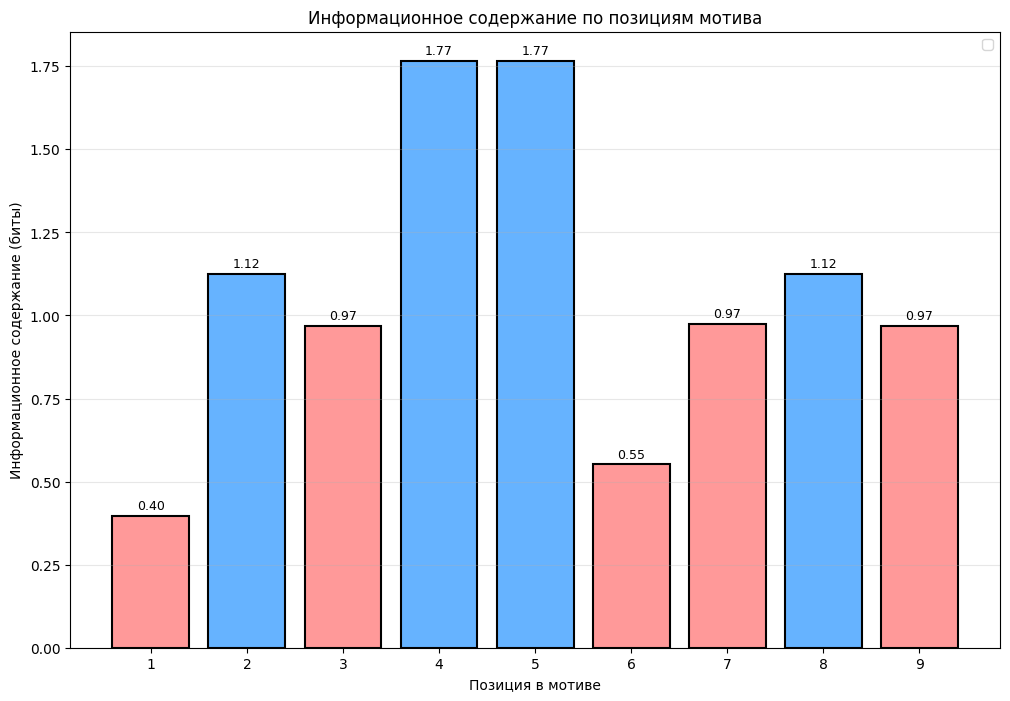

In [13]:
plt.figure(figsize=(12, 8))
positions = range(1, seq_length + 1)
colors = ['#ff9999' if ic < 1.0 else '#66b3ff' for ic in ic_values]
bars = plt.bar(positions, ic_values, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Позиция в мотиве')
plt.ylabel('Информационное содержание (биты)')
plt.title('Информационное содержание по позициям мотива')
plt.xticks(positions)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, ic) in enumerate(zip(bars, ic_values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{ic:.2f}', ha='center', va='bottom', fontsize=9)

plt.legend()
plt.show()


Видим, что важными позициями в мотиве (>1 бит) являются позиции 2, 4, 5, 8

Для наглядности сделаем красивое !визуальное выравнивание:

In [15]:
threshold = 1.0
alignment_matrix = []
for seq in sites:
    formatted_seq = []
    for pos, nuc in enumerate(seq):
        if ic_values[pos] >= threshold:
            formatted_seq.append(f"\033[1m{nuc}\033[0m")
        else:
            formatted_seq.append(nuc)
    alignment_matrix.append(''.join(formatted_seq))
    print(''.join(formatted_seq))

GAGGTAAAC
TCCGTAAGC
CAGGTTGGA
ACAGTCAGC
TAGGTCAGC
CAGGTCAGC
CAGGTCGAT
CAGGTCAGC
CAGGTCAGC
CAGGTTGGC


Визуальный осмотр показал, что действительно совпадают важные позиции
кор-мотива и с визуальным выделением консервативных и вариабельных позиций